# CatBoost - еще одна библиотека для градиентного бустинга над решающими деревьями  

* https://catboost.ai/en/docs/concepts/algorithm-main-stages_cat-to-numberic

## Какие деревья строятся в разных реализациях буcтинга?

![some_trees](pic/some_trees.png )  
  
    
- LightGBM не симметричные глубокие деревья (leaf-wise)
- XGBoost не симметричные глубокие деревья (leaf-wise), до недавнего времени были полные несимметричные деревья (level-wise)
- CatBoost строит полные симметричные деревья (oblivious tree), как следствие быстрый inference

## Как модели работают с категориальными признаками?

_Что вообще можно сделать?_
- One Hot Encoding
- Factorize
- Label Encoding

#### XGBoost
- Никак

#### CatBoost
1. Сортирует объекты в случайном порядке, разбивает на подвыборки
2. Переводит метку из категории в целое значение
3. Все категориальные признаки трансформируются в числовое значение по формуле:   
  
$$ avgTarget = \frac{countInClass + prior}{totalCount+1} $$



#### LightGBM
-  Аналогично CatBoost не требует OhE

In [ ]:
# !pip install catboost

# Import

In [1]:
import pandas as pd
import numpy as np
np.set_printoptions(precision=4)
import catboost
print(catboost.__version__)
import matplotlib.pyplot as plt
import seaborn as sns

1.2.5


# Data

In [2]:
from catboost.datasets import amazon
(train_df, test_df) = amazon()
train_df.head()

,ACTION,RESOURCE,MGR_ID,ROLE_ROLLUP_1,ROLE_ROLLUP_2,ROLE_DEPTNAME,ROLE_TITLE,ROLE_FAMILY_DESC,ROLE_FAMILY,ROLE_CODE
0,1,39353,85475,117961,118300,123472,117905,117906,290919,117908
1,1,17183,1540,117961,118343,123125,118536,118536,308574,118539
2,1,36724,14457,118219,118220,117884,117879,267952,19721,117880
3,1,36135,5396,117961,118343,119993,118321,240983,290919,118322
4,1,42680,5905,117929,117930,119569,119323,123932,19793,119325


In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32769 entries, 0 to 32768
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   ACTION            32769 non-null  int64
 1   RESOURCE          32769 non-null  int64
 2   MGR_ID            32769 non-null  int64
 3   ROLE_ROLLUP_1     32769 non-null  int64
 4   ROLE_ROLLUP_2     32769 non-null  int64
 5   ROLE_DEPTNAME     32769 non-null  int64
 6   ROLE_TITLE        32769 non-null  int64
 7   ROLE_FAMILY_DESC  32769 non-null  int64
 8   ROLE_FAMILY       32769 non-null  int64
 9   ROLE_CODE         32769 non-null  int64
dtypes: int64(10)
memory usage: 2.5 MB


In [5]:
train_df['ACTION'].value_counts()

ACTION
1    30872
0     1897
Name: count, dtype: int64

In [9]:
y = train_df.ACTION
X = train_df.drop('ACTION', axis=1)

In [7]:
cat_features = list(range(0, X.shape[1]))
print(cat_features)

[0, 1, 2, 3, 4, 5, 6, 7, 8]


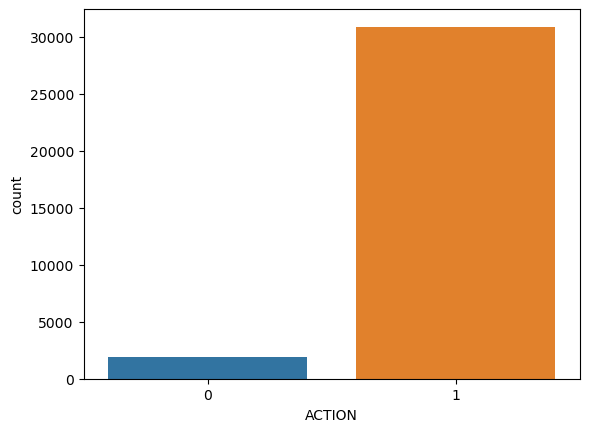

In [14]:
sns.countplot(train_df,x='ACTION')
plt.show()

# Training a Model 

In [15]:
from catboost import CatBoostClassifier

In [16]:
model = CatBoostClassifier(iterations=100)
model.fit(X, y, cat_features=cat_features, verbose=10)

Learning rate set to 0.377604
0:	learn: 0.4528598	total: 103ms	remaining: 10.2s
10:	learn: 0.1744186	total: 522ms	remaining: 4.22s
20:	learn: 0.1676119	total: 1.13s	remaining: 4.26s
30:	learn: 0.1652446	total: 1.58s	remaining: 3.52s
40:	learn: 0.1633644	total: 2.08s	remaining: 3s
50:	learn: 0.1621892	total: 3.03s	remaining: 2.91s
60:	learn: 0.1609164	total: 4.19s	remaining: 2.68s
70:	learn: 0.1594572	total: 4.82s	remaining: 1.97s
80:	learn: 0.1585876	total: 5.26s	remaining: 1.23s
90:	learn: 0.1573593	total: 5.71s	remaining: 565ms
99:	learn: 0.1566977	total: 6.16s	remaining: 0us


In [17]:
model.predict_proba(X)

array([[0.0098, 0.9902],
       [0.0101, 0.9899],
       [0.0579, 0.9421],
       ...,
       [0.0118, 0.9882],
       [0.1891, 0.8109],
       [0.0235, 0.9765]])

# Work with the data

Существует несколько способов передачи набора данных в обучение с помощью X, y или с помощью `pool` – это класс для хранения набора данных. 
Вы можете использовать `pool`, если в данных есть не только X и y (например, он имеет веса или группы выборок) или если набор данных большой и требуется много времени, чтобы прочитать его в python.



In [18]:
from catboost import Pool
from sklearn.model_selection import train_test_split

data = train_test_split(X, y, test_size=0.2, random_state=0)
X_train, X_validation, y_train, y_validation = data

train_pool = Pool(
    data=X_train, 
    label=y_train, 
    cat_features=cat_features
)

validation_pool = Pool(
    data=X_validation, 
    label=y_validation, 
    cat_features=cat_features
)

# Visualization

In [19]:
model = CatBoostClassifier(
    iterations=50,
    learning_rate=0.5,
    custom_loss=['AUC', 'Accuracy']
)

model.fit(
    train_pool,
    eval_set=validation_pool,
    verbose=False,
    plot=True
);

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

# Cross-Validation

In [ ]:
from catboost import cv

params = {
    'loss_function': 'Logloss',
    'iterations': 80,
    'custom_loss': 'AUC',
    'learning_rate': 0.5,
}

cv_data = cv(
    params = params,
    pool = train_pool,
    fold_count=5,
    shuffle=True,
    partition_random_seed=0,
    plot=True,
    verbose=False
)

In [ ]:
cv_data.head(10)

## Grid Search CV

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "learning_rate": [0.001, 0.01, 0.5],
}

clf = CatBoostClassifier(
    iterations=20, 
    cat_features=cat_features, 
    verbose=20
)
grid_search = GridSearchCV(clf, param_grid=param_grid, cv=3)
results = grid_search.fit(X_train, y_train)
results.best_estimator_.get_params()

# Stopping the algorithm early

In [ ]:
model_with_early_stop = CatBoostClassifier(
    eval_metric='AUC',
    iterations=200,
    learning_rate=0.5,
    early_stopping_rounds=20
)
model_with_early_stop.fit(
    train_pool,
    eval_set=validation_pool,
    verbose=False,
    plot=True
);

# FPR-FNR curves

In [ ]:
import matplotlib.pyplot as plt
from catboost.utils import get_roc_curve
from catboost.utils import get_fpr_curve
from catboost.utils import get_fnr_curve

curve = get_roc_curve(model, validation_pool)
(fpr, tpr, thresholds) = curve

(thresholds, fpr) = get_fpr_curve(curve=curve)
(thresholds, fnr) = get_fnr_curve(curve=curve)

In [ ]:
plt.figure(figsize=(9, 5))
style = {'alpha':0.5, 'lw':2}

plt.plot(thresholds, fpr, color='blue', label='FPR', **style)
plt.plot(thresholds, fnr, color='green', label='FNR', **style)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)
plt.xlabel('Threshold', fontsize=16)
plt.ylabel('Error Rate', fontsize=16)
plt.title('FPR-FNR curves', fontsize=20)
plt.legend(loc="lower left", fontsize=16);

In [ ]:
from catboost.utils import select_threshold

print(select_threshold(model, validation_pool, FNR=0.01))
print(select_threshold(model, validation_pool, FPR=0.01))

# Feature importance

In [ ]:
np.array(model.get_feature_importance(prettified=True))

# Saving Model

In [ ]:
model = CatBoostClassifier(iterations=10)
model.fit(train_pool, eval_set=validation_pool, verbose=False)
model.save_model('catboost_model.bin')
model.save_model('catboost_model.json', format='json')

# Loading the model

In [ ]:
model.load_model('catboost_model.bin')
print(model.get_params())
print(model.learning_rate_)